# 02 — SQL Business Analysis

**Spotify Content Performance Analytics** — Phase 2 SQL analytics layer.

Presents the results of `sql/01_data_quality.sql`, `sql/02_kpi_summary.sql`,
and `sql/03_segment_analysis.sql`, run against the DuckDB database built from
the primary analytical dataset. Each query in the `.sql` files was developed
interactively (question → grain → hand-written query → critique → revision)
except where noted in the file headers; this notebook narrates the results,
it does not re-derive the SQL.

**Scope reminder:** this is observational catalog data of unknown sampling
frame and unknown collection time. No causal claims are made anywhere below.
Every percentage/share describes "tracks in this dataset." Genre-conditioned
findings are always scoped to "tracks in this dataset with an observed
primary genre" (39.7% of the dataset — see notebook 01 and
`reports/data_quality_report.md`).

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../data/processed/spotify.duckdb", read_only=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

def run(sql):
    return con.execute(sql).fetchdf()

def load_statements(path):
    """Split a .sql file into executable statements, ignoring semicolons
    that appear inside prose comments (full-line -- comments are stripped
    before splitting)."""
    sql_text = open(path).read()
    lines = [l for l in sql_text.splitlines() if not l.strip().startswith("--")]
    clean = "\n".join(lines)
    return [s.strip() + ";" for s in clean.split(";") if s.strip()]

## 1. Data quality (recap)

`sql/01_data_quality.sql` reproduces the audit from notebook 01 as an
independent SQL check. Full narrative is in
`reports/data_quality_report.md`; here we just confirm the database matches.

In [2]:
print("Total observations:", run("SELECT COUNT(*) AS n FROM tracks_primary")["n"].iloc[0])
print("Remaining exact duplicates (should be 0):",
      run("SELECT SUM(CASE WHEN exact_duplicate_flag THEN 1 ELSE 0 END) AS n FROM tracks_primary")["n"].iloc[0])

Total observations: 277937
Remaining exact duplicates (should be 0): 0.0


## 2. Current popularity of tracks by release decade (Q1)

Read as "current popularity of tracks released in each decade" / "popularity
at the dataset's collection time" — never as "performance by decade."
`popularity_score` is a snapshot at an unknown collection moment, and older
decades in this dataset are a recency/survivorship-filtered subset of
everything ever released then, not a full accounting of it. The 1890s/1900s/
1910s (n=13/10/18) are shown but should not be over-interpreted.

In [3]:
queries_02 = load_statements("../sql/02_kpi_summary.sql")
queries_03 = load_statements("../sql/03_segment_analysis.sql")
q1 = run(queries_02[0])
q1

,release_decade_clean,track_count,median_popularity_score,mean_popularity_score
0,1890,13,5.0,5.62
1,1900,10,19.0,22.70
2,1910,18,9.5,11.33
3,1920,68,17.5,17.44
4,1930,123,10.0,17.34
5,1940,99,30.0,31.40
6,1950,1349,29.0,28.10
7,1960,4010,31.0,29.73
8,1970,6515,33.0,31.37
9,1980,8244,32.0,30.43


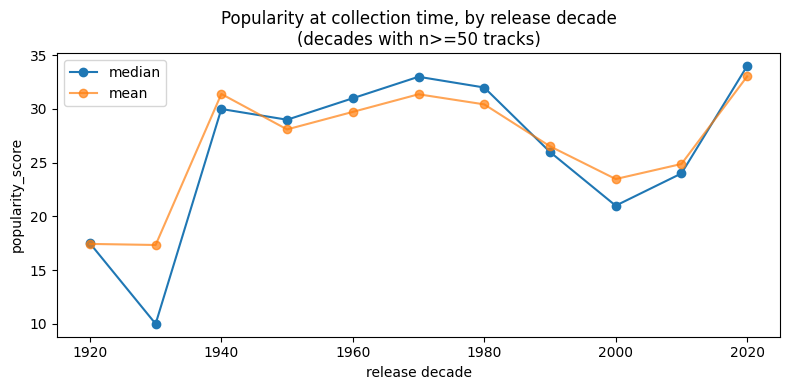

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plotted = q1[q1["track_count"] >= 50]
ax.plot(plotted["release_decade_clean"], plotted["median_popularity_score"], marker="o", label="median")
ax.plot(plotted["release_decade_clean"], plotted["mean_popularity_score"], marker="o", label="mean", alpha=0.7)
ax.set_title("Popularity at collection time, by release decade\n(decades with n>=50 tracks)")
ax.set_xlabel("release decade")
ax.set_ylabel("popularity_score")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Popularity and high-popularity share by genre (Q2, Q3)

Among tracks in this dataset **with an observed primary genre** only.

In [5]:
q2 = run(queries_02[1])
q3 = run(queries_02[2])
q2

,artist_1_genre_1,track_count,median_popularity_score,mean_popularity_score
0,pop,28410,42.0,37.98
1,r&b,3572,40.0,36.89
2,reggae,1567,39.0,36.49
3,rap,7289,39.0,36.00
4,country,5643,38.0,35.22
5,hip hop,14284,38.0,35.19
6,alternative,2012,36.0,30.90
7,latin,358,33.0,32.27
8,soul,2261,33.0,30.02
9,metal,6964,33.0,30.81


In [6]:
q3

,artist_1_genre_1,track_count,high_popularity_count,high_popularity_share_pct
0,reggae,1567,214.0,13.66
1,pop,28410,2430.0,8.55
2,rap,7289,559.0,7.67
3,hip hop,14284,914.0,6.40
4,latin,358,22.0,6.15
5,r&b,3572,165.0,4.62
6,country,5643,252.0,4.47
7,funk,2060,87.0,4.22
8,rock,17908,643.0,3.59
9,metal,6964,219.0,3.14


**Note the divergence between median rank (Q2) and high-popularity-share
rank (Q3):** `reggae` has the highest high-popularity share (13.66%) despite
a lower median than `pop`, indicating a relatively heavier upper tail rather
than a uniformly higher distribution. `classical`, `blues`, and `jazz` have
both low medians and very thin high-popularity tails (4, 4, and 11 tracks
respectively) despite large group sizes — a real pattern, not a small-sample
artifact.

## 4. Genre coverage by decade (Q4)

This is a coverage question, so it is **not** restricted to genre-labeled
tracks — it measures what fraction of each decade's tracks have a genre at
all.

In [7]:
q4 = run(queries_02[3])
q4

,release_decade_clean,track_count,tracks_with_genre,genre_coverage_pct
0,1920,68,38.0,55.88
1,1930,123,41.0,33.33
2,1940,99,22.0,22.22
3,1950,1349,358.0,26.54
4,1960,4010,1819.0,45.36
5,1970,6515,4313.0,66.20
6,1980,8244,4792.0,58.13
7,1990,19580,10220.0,52.20
8,2000,40579,18051.0,44.48
9,2010,108479,44705.0,41.21


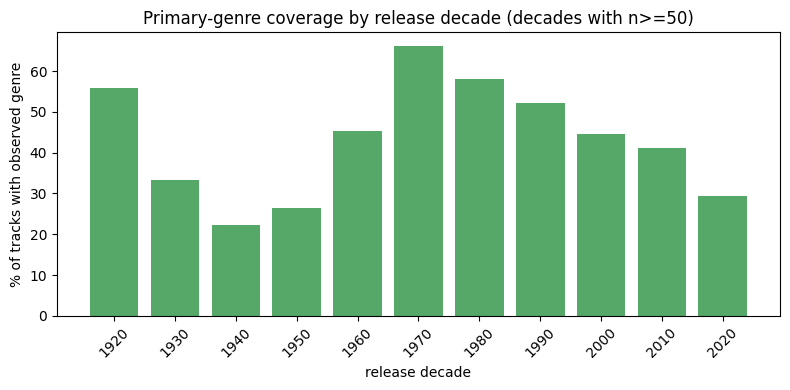

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(q4["release_decade_clean"].astype(str), q4["genre_coverage_pct"], color="#55A868")
ax.set_title("Primary-genre coverage by release decade (decades with n>=50)")
ax.set_ylabel("% of tracks with observed genre")
ax.set_xlabel("release decade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**This is one of the more important findings in this project.** Genre
coverage is far from stable across decades (22% in the 1940s up to 66% in
the 1970s), and critically, **2020s coverage is only 29.3%** despite being
one of the largest decade groups in the dataset. Any genre-by-decade
comparison must be read as conditioned on "tracks in this dataset with an
observed primary genre," not as representative of that decade's full
output — the 2020s in particular are under-represented in genre-conditioned
views relative to their true size in this dataset.

## 5. Popularity by album type (Q5) and a factual check on why (Q10)

Q5 found singles have the highest median popularity, but albums have a
slightly higher high-popularity share, and compilations are lowest across
every measure.

In [9]:
q5 = run(queries_02[4])
q5

,album_type,track_count,median_popularity_score,mean_popularity_score,high_popularity_count,high_popularity_share_pct
0,single,92835,33.0,30.98,2702.0,2.91
1,album,161872,27.0,27.31,5056.0,3.12
2,compilation,23230,13.0,18.44,169.0,0.73


Q5 raised release-period age as a *possible, untested* explanation for
compilations' lower popularity. Q10 (`sql/03_segment_analysis.sql`) checks
this factually rather than leaving it as a guess.

In [10]:
q10 = run(queries_03[5])
q10

,album_type,track_count,median_release_year,pct_released_2000_or_earlier
0,compilation,23229,2010.0,48.39
1,album,161870,2012.0,40.83
2,single,92834,2021.0,3.54


**Factual result, not a causal claim:** compilations do skew markedly
older (median release year 2010, 48.4% released 2000-or-earlier) versus
singles (median 2021, only 3.5% that old). But albums also have a large
older-release share (40.8%, median 2012) while still holding a much higher
median popularity than compilations (27 vs. 13, from Q5) — so release-period
age alone does **not** fully explain the compilation popularity gap. The
hypothesis is partially supported, not confirmed as a complete explanation.

## 6. Primary-genre ranking within release decades (Q6)

Top genre by track count in each decade, using `RANK()` so ties share a
rank rather than being arbitrarily broken.

In [11]:
q6 = run(queries_03[0])
q6[q6["genre_rank"] <= 3]

,release_decade_clean,artist_1_genre_1,track_count,genre_rank
0,1890,blues,1,1
1,1900,jazz,2,1
2,1900,classical,1,2
3,1900,rock,1,2
4,1910,classical,7,1
5,1920,blues,35,1
6,1920,classical,1,2
7,1920,country,1,2
8,1920,jazz,1,2
9,1930,blues,25,1


## 7. Genre share within decade (Q7)

Each genre's percentage of that decade's genre-labeled tracks, computed with
a window aggregate (`SUM() OVER (PARTITION BY decade)`, no `ORDER BY` inside
the window — the full-partition total, not a running sum).

In [12]:
q7 = run(queries_03[1])
q7[q7["release_decade_clean"].isin([2010, 2020])]

,release_decade_clean,artist_1_genre_1,track_count,decade_genre_labeled_total,genre_share_pct
104,2010,pop,13055,44705.0,29.20
105,2010,hip hop,6718,44705.0,15.03
106,2010,rock,5399,44705.0,12.08
107,2010,rap,3429,44705.0,7.67
108,2010,metal,2681,44705.0,6.00
109,2010,country,2450,44705.0,5.48
110,2010,classical,1888,44705.0,4.22
111,2010,jazz,1770,44705.0,3.96
112,2010,folk,1326,44705.0,2.97
113,2010,r&b,1328,44705.0,2.97


`pop` is the largest genre share in both the 2010s (29.2%) and 2020s
(31.6%), with `hip hop` a consistent second. Remember this is a share of the
*genre-labeled* subset of each decade only — the 2020s' genre-labeled subset
is itself a smaller, non-random 29.3% of all 2020s tracks (§4).

## 8. Genre availability and top genres by popularity tier (Q8)

The strongest tier-level confirmation of the genre-availability bias in this
project: genre coverage rises sharply and monotonically with popularity
tier.

In [13]:
q8a = run(queries_03[2])
q8a

,popularity_tier,track_count,tracks_with_genre,genre_coverage_pct
0,low,161824,53101.0,32.81
1,moderate,108186,51597.0,47.69
2,high,7927,5688.0,71.75


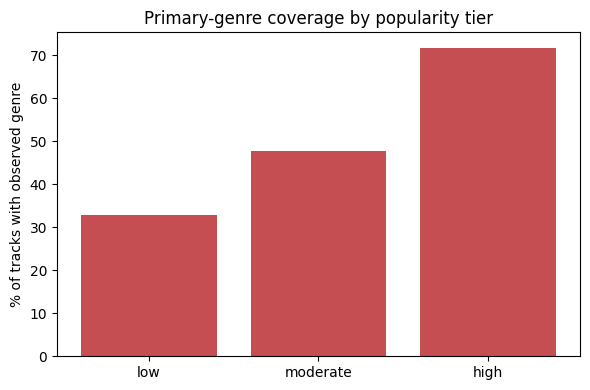

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
tier_order = ["low", "moderate", "high"]
q8a_ordered = q8a.set_index("popularity_tier").loc[tier_order].reset_index()
ax.bar(q8a_ordered["popularity_tier"], q8a_ordered["genre_coverage_pct"], color="#C44E52")
ax.set_title("Primary-genre coverage by popularity tier")
ax.set_ylabel("% of tracks with observed genre")
plt.tight_layout()
plt.show()

**This is not evidence that having a genre causes higher popularity.**
Both are plausibly downstream of a common factor — e.g. an artist/track
being established enough on the platform to have complete metadata *and* to
have accumulated plays. No causal direction is asserted.

In [15]:
q8b = run(queries_03[3])
q8b

,popularity_tier,artist_1_genre_1,track_count,genre_rank_in_tier
0,low,pop,10735,1
1,low,rock,9107,2
2,low,hip hop,6157,3
3,low,jazz,3988,4
4,low,classical,3859,5
5,moderate,pop,15245,1
6,moderate,rock,8158,2
7,moderate,hip hop,7213,3
8,moderate,rap,3684,4
9,moderate,metal,3196,5


## 9. Primary vs. sensitivity dataset — does deduplication matter? (Q9)

Independent SQL confirmation of the same comparison in
`reports/data_quality_report.md` §17 and `src/metrics.py` — computed here
directly in SQL rather than pandas, and matching those figures to 3+ decimal
places.

In [16]:
q9 = run(queries_03[4])
q9

,dataset,track_count,median_popularity_score,mean_popularity_score,high_popularity_share_pct,primary_genre_coverage_pct
0,primary,277937,28.0,27.7967,2.8521,39.7162
1,sensitivity,277846,28.0,27.7984,2.8516,39.7152


**Deltas are trivial for every KPI shown here.** No popularity, genre,
or high-popularity-share conclusion in this project would change depending
on whether `tracks_primary` or `tracks_sensitivity` was used. This is
reported plainly, not overstated as a general claim that deduplication
"doesn't matter" — it means it does not matter *for these specific KPIs, on
this dataset*.

## 10. Summary

- Popularity-by-decade, genre, and album-type comparisons all confirm the
  measurement caveats established in notebook 01: popularity is a snapshot,
  release period is entangled with recency/survivorship, and genre
  availability is systematically incomplete (worst in the 2020s, best in the
  high-popularity tier).
- The compilation-popularity hypothesis from Q5 was checked factually (Q10)
  and found to be only a partial explanation, not a confirmed cause.
- Primary vs. sensitivity dataset deltas are trivial across every core KPI —
  the retained `(track, artist_1)` repeats are not distorting the headline
  descriptive results.
- No causal claims are made anywhere in this analysis.

**Next steps are listed under "Phase 3 Recommendations" in the phase-end
report — no modeling, clustering, or dashboards have been started.**